In [10]:
import rasterio
import rasterio.plot
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft2, fftshift
import skgstat as skg
import logging
import sys
from pathlib import Path
from rasterio.enums import Resampling

# Instantiate logger at the module level per HPC requirements
logger = logging.getLogger(__name__)

# Configure logging to default to stdout for interactive notebook testing
logging.basicConfig(level=logging.INFO, stream=sys.stdout, 
                    format='%(asctime)s - %(levelname)s - %(message)s')

logger.info("Environment initialized and logger configured.")

2026-08-02 18:14:41,615 - INFO - Environment initialized and logger configured.


In [2]:
import earthaccess as ea
import rioxarray as rio
from rasterio.enums import Resampling

auth = ea.login()
if not auth.authenticated:
    auth.login(strategy="interactive", persist=True)

# Open file

In [3]:
target_granules = [
    "SNEX20_QSI_SD_0.5M_USUTLC_20210318_20210318"
]

print("Searching for SNEX20_QSI_SD granules...")
broad_grans = ea.search_data(
    short_name='SNEX20_QSI_SD',
    cloud_hosted=True,
    temporal=('2021-03-18', '2021-03-19'),
)

# Strict filtering by exact filename match
lidar_grans = [
    g for g in broad_grans 
    if any(target in (g.path if hasattr(g, 'path') else str(g)) for target in target_granules)
]

print(f"Filtered down to {len(lidar_grans)} exact granules.")

print(lidar_grans)

# Open the fileset using earthaccess
lidar_file = ea.open(lidar_grans)[0]
slc_lidar = rio.open_rasterio(lidar_file, chunks={'x': 2000, 'y': 2000}).squeeze()

Searching for SNEX20_QSI_SD granules...
2026-08-02 18:08:56,475 - INFO - Granules found: 3
Filtered down to 1 exact granules.
[Collection: {'EntryTitle': 'SnowEx20-21 QSI Lidar Snow Depth 0.5m UTM Grid V001'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -111.72, 'Latitude': 40.5202}, {'Longitude': -111.615, 'Latitude': 40.5208}, {'Longitude': -111.615, 'Latitude': 40.5984}, {'Longitude': -111.721, 'Latitude': 40.5978}, {'Longitude': -111.72, 'Latitude': 40.5202}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2021-03-18T00:00:01.000Z', 'EndingDateTime': '2021-03-18T23:59:59.000Z'}}
Size(MB): 261.982
Data: ['https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/SNOWEX/SNEX20_QSI_SD/1/2021/03/18/SNEX20_QSI_SD_0.5M_USUTLC_20210318_20210318.tif']]
2026-08-02 18:08:56,804 - INFO - Opening 1 granules, approx size: 0.26 GB


QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 3600.26it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:01<00:00,  1.38s/it]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 16070.13it/s]


In [6]:
slc_lidar.rio.crs

CRS.from_wkt('PROJCS["unnamed",GEOGCS["Unknown datum based upon the GRS 1980 ellipsoid",DATUM["Not_specified_based_on_GRS_1980_ellipsoid",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6019"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4019"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

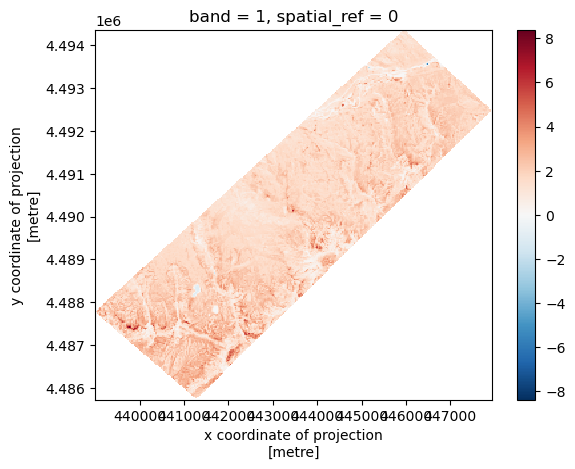

In [11]:
slc_lidar.rio.write_crs('EPSG:6341')
slc_lidar.rio.reproject(dst_crs='EPSG:6341', resolution=(30), resampling=Resampling.average).plot()

# Helper functions

In [19]:
def preprocess_lidar(lidar_array):
    """
    Cleans the lidar array by masking NaNs and flattening it for geostatistics.
    """
    # Create a mask for valid data
    valid_mask = ~np.isnan(lidar_array)
    
    # Create coordinate grids
    y_indices, x_indices = np.indices(lidar_array.shape)
    
    # Extract valid coordinates and values
    coords = np.column_stack((x_indices[valid_mask], y_indices[valid_mask]))
    values = lidar_array[valid_mask]
    
    return coords, values, valid_mask

def plot_empirical_variogram(coords, values, pixel_size, maxlag=None, sample_size=5000):
    """
    Calculates and plots the omnidirectional empirical variogram.
    Note: Subsampling is strictly required because variogram computation 
    scales at O(N^2).
    """
    print("Calculating Empirical Variogram...")
    
    # Randomly subsample to prevent memory/computation overload
    if len(values) > sample_size:
        idx = np.random.choice(len(values), sample_size, replace=False)
        coords_sample = coords[idx] * pixel_size
        values_sample = values[idx]
    else:
        coords_sample = coords * pixel_size
        values_sample = values

    # Compute variogram
    V = skg.Variogram(
        coords_sample, 
        values_sample, 
        model='spherical', 
        maxlag=maxlag, 
        n_lags=25
    )
    
    fig, ax = plt.subplots(figsize=(8, 5))
    V.plot(axes=ax, show=False)
    ax.set_title("Empirical Variogram")
    ax.set_xlabel("Lag Distance (m)")
    ax.set_ylabel("Semivariance")
    plt.tight_layout()
    plt.show()
    
    return V

def plot_2d_power_spectrum(lidar_array, pixel_size):
    """
    Calculates the 2D Fourier Power Spectrum and computes the 1D radially 
    averaged power spectrum to identify scale breaks.
    """
    print("Calculating 2D Fourier Power Spectrum...")
    
    # Replace NaNs with the mean to prevent FFT artifacts
    clean_array = np.nan_to_num(lidar_array, nan=np.nanmean(lidar_array))
    
    # Calculate 2D FFT and Shift zero frequency to center
    F = fft2(clean_array)
    F_shift = fftshift(F)
    
    # Calculate Power Spectral Density (PSD)
    psd_2d = np.abs(F_shift)**2
    
    # --- Radial Averaging for 1D Power Spectrum ---
    y, x = np.indices(psd_2d.shape)
    center = (psd_2d.shape[0] // 2, psd_2d.shape[1] // 2)
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    r = r.astype(int)
    
    tbin = np.bincount(r.ravel(), psd_2d.ravel())
    nr = np.bincount(r.ravel())
    radial_psd = tbin / nr
    
    # Calculate spatial frequencies
    spatial_freq = np.fft.fftfreq(lidar_array.shape[0], d=pixel_size)
    spatial_freq = spatial_freq[:len(radial_psd)]
    
    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 2D PSD
    im = ax1.imshow(np.log10(psd_2d + 1e-10), cmap='viridis')
    ax1.set_title("2D Power Spectrum (Log Scale)")
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
    
    # 1D Radial PSD (Log-Log)
    valid_idx = spatial_freq > 0
    ax2.loglog(spatial_freq[valid_idx], radial_psd[valid_idx], 'b.-')
    ax2.set_title("1D Radially Averaged Power Spectrum")
    ax2.set_xlabel("Spatial Frequency (1/m)")
    ax2.set_ylabel("Power")
    ax2.grid(True, which="both", ls="--")
    
    plt.tight_layout()
    plt.show()

def plot_directional_anisotropy(coords, values, pixel_size, sample_size=5000):
    """
    Evaluates directional bias by calculating variograms at 0, 45, 90, and 135 degrees.
    """
    print("Calculating Directional Variograms...")
    
    if len(values) > sample_size:
        idx = np.random.choice(len(values), sample_size, replace=False)
        coords_sample = coords[idx] * pixel_size
        values_sample = values[idx]
    else:
        coords_sample = coords * pixel_size
        values_sample = values

    angles = [0, 45, 90, 135]
    tolerance = 15 # degrees of tolerance around the target angle

    fig, ax = plt.subplots(figsize=(8, 5))
    
    for angle in angles:
        V_dir = skg.DirectionalVariogram(
            coords_sample, 
            values_sample, 
            azimuth=angle, 
            tolerance=tolerance, 
            maxlag=None, 
            n_lags=20
        )
        ax.plot(V_dir.bins, V_dir.experimental, marker='o', label=f'{angle}°')

    ax.set_title("Directional Variograms (Anisotropy)")
    ax.set_xlabel("Lag Distance (m)")
    ax.set_ylabel("Semivariance")
    ax.legend(title="Azimuth")
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

import numpy as np
import xarray as xr
import skgstat as skg
import logging

logger = logging.getLogger(__name__)

def prep_variogram_data(da: xr.DataArray, sample_size: int = 5000):
    """
    Prepares xarray DataArray for scikit-gstat variogram analysis by 
    flattening, removing NaNs, and subsampling.
    """
    # 1. Extract 1D arrays
    values = da.values.flatten()
    X, Y = np.meshgrid(da.x.values, da.y.values)
    coords = np.column_stack((X.flatten(), Y.flatten()))

    # 2. Mask NoData/NaN values
    valid_mask = ~np.isnan(values)
    clean_values = values[valid_mask]
    clean_coords = coords[valid_mask]

    # 3. Subsample (Variograms are computationally expensive: O(N^2))
    if len(clean_values) > sample_size:
        logger.info(f"Subsampling variogram data to {sample_size} points.")
        idx = np.random.choice(len(clean_values), size=sample_size, replace=False)
        final_values = clean_values[idx]
        final_coords = clean_coords[idx]
    else:
        final_values = clean_values
        final_coords = clean_coords
        
    return final_coords, final_values

def sanitize_variogram_inputs(coords, values):
    """
    Ensures coordinates and values are correctly shaped and free of NaNs.
    """
    # 1. Flatten if necessary
    if values.ndim > 1:
        values = values.flatten()
        
    # Ensure coords is an (N, 2) array
    if isinstance(coords, tuple) or coords.ndim > 2 or coords.shape[1] != 2:
        # Assuming coords might have been passed as (x_grid, y_grid)
        if isinstance(coords, tuple) and len(coords) == 2:
            coords = np.column_stack((coords[0].flatten(), coords[1].flatten()))
        elif coords.shape[0] == 2:
            coords = coords.T # Transpose from (2, N) to (N, 2)
        else:
            raise ValueError(f"Unexpected coordinates shape: {coords.shape}. Expected (N, 2).")

    # 2. Filter out NaNs (Critical for external libraries)
    valid_mask = ~np.isnan(values)
    
    # Optional: check if coordinates contain NaNs
    valid_mask &= ~np.isnan(coords).any(axis=1)

    clean_coords = coords[valid_mask]
    clean_values = values[valid_mask]
    
    logger.info(f"Variogram inputs sanitized. N={len(clean_values)} samples retained.")
    
    return clean_coords, clean_values


Calculating Empirical Variogram...


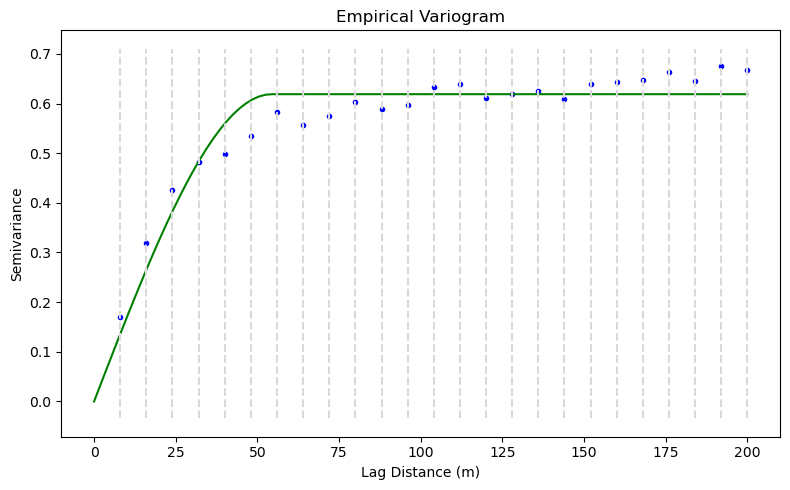

< spherical Semivariogram fitted to 25 bins >

In [36]:
lidar_data = slc_lidar.values
pixel_resolution = 0.5

# 1. Preprocess
coords, values, mask = preprocess_lidar(lidar_data)

# 2. Run Analyses
plot_empirical_variogram(coords, values, pixel_size=pixel_resolution, maxlag=200, sample_size=10000)

Calculating 2D Fourier Power Spectrum...


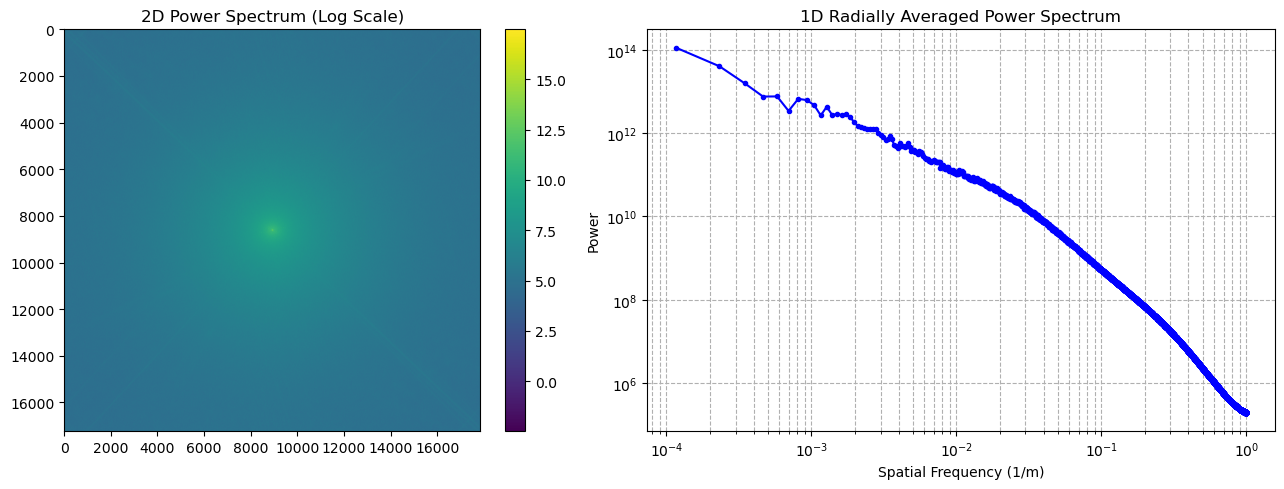

In [14]:
plot_2d_power_spectrum(lidar_data, pixel_size=pixel_resolution)


In [21]:
coords_sample, values_sample = prep_variogram_data(slc_lidar)

2026-08-02 18:21:21,508 - INFO - Subsampling variogram data to 5000 points.
[[ 445618.75 4491794.75]
 [ 446202.75 4493411.25]
 [ 447263.75 4491971.75]
 ...
 [ 441164.75 4489599.25]
 [ 440772.75 4486680.25]
 [ 445473.25 4491406.75]]


Calculating Directional Variograms...


ValueError: setting an array element with a sequence.

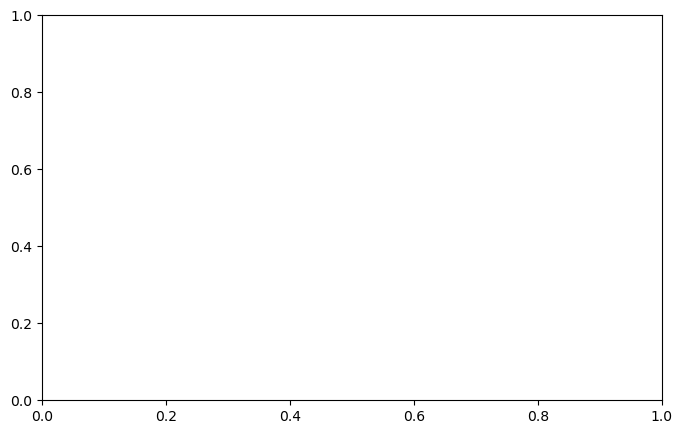

In [30]:

plot_directional_anisotropy(coords_final, values_final, pixel_size=pixel_resolution)